### Import Library

In [ ]:
import os
import pandas as pd
import torch
from argparse import Namespace
from torch.utils.data import DataLoader

import sys
# sys.path.insert(1, "/Users/yeojisu/Documents/House-Price-Index-Prediction")

from config.config_KR import *
from model.dfm_model import * 
from model.var_model import *
from model.kalman_filter import *
from utils.deep_learning import *
from utils.data_loader import *
from utils.visualization import *

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="A date index has been provided, but it has no associated frequency information")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
from model.ablation_model.MLPpatchLatentFFT import Model # Choose Model
from model.ablation_model.MLPpatchLatentMA import Model


### Load Data

In [106]:
target_df = load_target_data(TARGET_PATH)
target_df_train = target_df[target_df.index < TEST_DATE]
target_df_test  = target_df[target_df.index >= TEST_DATE]

### Dynamic Factor Model (DFM)

In [107]:
dfm_results = run_dfm(target_df_train, target_df_test, REFERENCE_DATE, 5)
# train phase 
optimal_factors = dfm_results["optimal_factors"]
shared_component_final_train = dfm_results["shared_component_final_train"]
loadings     = dfm_results["loadings"]
scale_factor = dfm_results["scale_factor"]
offset       = dfm_results["offset"]

combined_array = dfm_results["combined_shared_component"]

factor_column_list = []
for i in range(optimal_factors):
    factor_column_list.append("factor"+str(i+1))

factor_df = pd.DataFrame(combined_array, columns=factor_column_list, index=target_df.index)


Optimization terminated successfully.
         Current function value: 18.458637
         Iterations: 17
         Function evaluations: 9882


In [108]:
df = load_feature_data(FEATURE_PATH, FEATURE_COLUMN, TRAIN_DATE)
df = pd.concat([df, factor_df], axis=1)
df = df.dropna()

In [109]:
# First-order difference
data_diff = df.diff().dropna()
# Select explanatory variables using Granger test (excluding target)
granger_values = granger_test(data_diff[data_diff.index < TEST_DATE], "factor1", maxlag=23)

{'call_rate': 8, 'bond_3yr': 23, 'loan_rate_avg': 23, 'KOSPI': 9, 'NASDAQ': 9, 'M2_KR': 12, 'M2_US': 12, 'broad_liquidity': 19, 'CPI_growth': 23, 'USD_KRW_rate': 8, 'GDP_growth': 21, 'res_start': 2, 'res_permit': 4, 'factor2': 12}


In [110]:
data = data_diff[data_diff.index < TEST_DATE]
target = "factor2"
maxlag=23
granger_values = {}
significant_results = {}
for col in data.columns:
    if col != target:
        test_result = grangercausalitytests(data[[target, col]], maxlag=maxlag, verbose=False)
        sig_lags = {}
        
        for lag, result in test_result.items():
            f = result[0]['ssr_chi2test'][0]
            p_value = result[0]['ssr_chi2test'][1]
            if p_value <= 0.05:
                sig_lags[lag] = [round(f,3), round(p_value,3)]
        if sig_lags:
            significant_results[col] = sig_lags
granger_values[target] = significant_results
print(significant_results)

{'call_rate': {1: [6.488, 0.011], 3: [9.911, 0.019], 4: [10.798, 0.029], 5: [12.64, 0.027], 6: [13.952, 0.03], 7: [14.757, 0.039], 8: [23.035, 0.003], 9: [31.802, 0.0], 10: [33.368, 0.0], 11: [33.155, 0.0], 12: [33.743, 0.001], 13: [37.232, 0.0], 14: [35.849, 0.001], 15: [44.582, 0.0], 16: [48.566, 0.0], 17: [52.375, 0.0], 18: [54.46, 0.0], 19: [56.025, 0.0], 20: [64.956, 0.0], 21: [65.709, 0.0], 22: [66.687, 0.0], 23: [66.514, 0.0]}, 'bond_3yr': {1: [19.42, 0.0], 2: [16.476, 0.0], 3: [20.949, 0.0], 4: [27.271, 0.0], 5: [32.657, 0.0], 6: [33.85, 0.0], 7: [32.128, 0.0], 8: [31.397, 0.0], 9: [34.164, 0.0], 10: [34.064, 0.0], 11: [35.736, 0.0], 12: [40.797, 0.0], 13: [44.297, 0.0], 14: [45.865, 0.0], 15: [47.327, 0.0], 16: [49.199, 0.0], 17: [69.458, 0.0], 18: [70.353, 0.0], 19: [72.238, 0.0], 20: [69.49, 0.0], 21: [72.635, 0.0], 22: [76.706, 0.0], 23: [87.693, 0.0]}, 'loan_rate_avg': {1: [15.38, 0.0], 2: [6.366, 0.041], 3: [8.613, 0.035], 9: [21.866, 0.009], 10: [24.679, 0.006], 11: [24.

### Vector Autoregression (VAR)

In [111]:
forecast_dfs = {} 
for i in range(optimal_factors):
    factor_name = f"factor{i+1}"
    forecast_dfs[factor_name] = var_forecast(df, factor_name, TEST_DATE, MAXLAG_FACTOR, SELECTED_LAG_FACTOR, FORECAST_SIZE)

{'call_rate': 8, 'bond_3yr': 23, 'loan_rate_avg': 23, 'KOSPI': 9, 'NASDAQ': 9, 'M2_KR': 12, 'M2_US': 12, 'broad_liquidity': 19, 'CPI_growth': 23, 'USD_KRW_rate': 8, 'GDP_growth': 21, 'res_start': 2, 'res_permit': 4, 'factor2': 12}
{'call_rate': 20, 'bond_3yr': 23, 'loan_rate_avg': 22, 'KOSPI': 22, 'KOSDAQ': 22, 'NASDAQ': 23, 'M2_KR': 23, 'M2_US': 18, 'broad_liquidity': 23, 'USD_KRW_rate': 22, 'GDP_growth': 23, 'res_permit': 20}


### Kalman Filter

In [ ]:
smoothed_factors = {} 
my_date = calculate_date_after_n_months(TRAIN_DATE,FORECAST_SIZE+SELECTED_LAG_FACTOR - 1)

for i in range(optimal_factors):
    factor_name = f"factor{i+1}"
    combined_series = pd.concat([df[factor_name][TRAIN_DATE:my_date], forecast_dfs[factor_name][factor_name]])
    smoothed = apply_kalman_filter(combined_series, KALMAN_OBSERVATION_COV, KALMAN_TRANSITION_COV)
    smoothed_factors[factor_name] = smoothed


### Deep Residual Learning

In [114]:
smoothed_factors_df = pd.concat(list(smoothed_factors.values()), axis=1)
smoothed_factors_df.columns = [f"factor{i+1}" for i in range(optimal_factors)]

common_index = target_df.index.intersection(smoothed_factors_df.index)
smoothed_factors_df = smoothed_factors_df.loc[common_index]
target_df_common = target_df.loc[common_index]

target_mean = target_df_train.mean().values
factors_adjusted = (smoothed_factors_df.values @ loadings.T) * scale_factor + target_mean + offset

resid = target_df_common - factors_adjusted
resid = resid.reset_index().rename(columns={"index": "Date"})
resid["Date"] = pd.to_datetime(resid["Date"])

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
  3%|▎         | 27/1000 [05:57<3:34:49, 13.25s/it]

Early stopping triggered at epoch 28
Training time: 0.4816617037568774


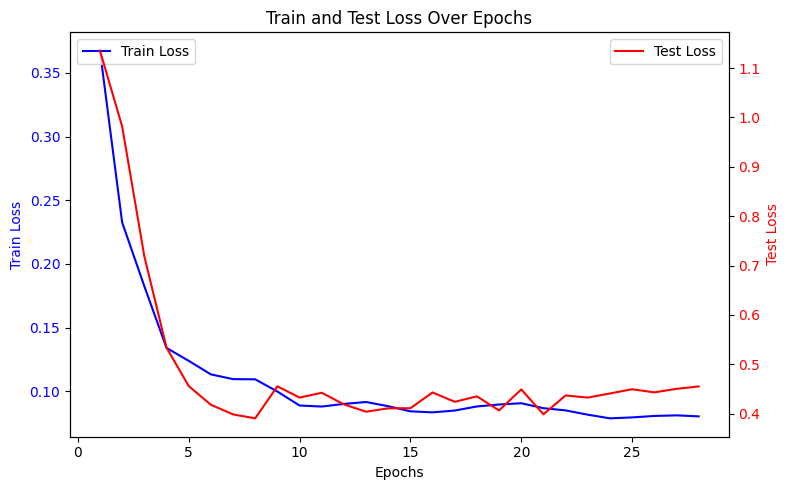

Inference time: 0.9756441116333008
Inference time: 4.07488489151001
Inference time: 0.5349640846252441
Inference time: 2.860574245452881
Test .................
Seoul_HPI: RMSE=15.953, MAE=13.062999725341797
Busan_HPI: RMSE=7.018, MAE=5.639999866485596
Daegu_HPI: RMSE=8.446, MAE=6.877999782562256
Incheon_HPI: RMSE=12.499, MAE=9.178000450134277
Gwangju_HPI: RMSE=9.376, MAE=7.515999794006348
Daejeon_HPI: RMSE=12.499, MAE=10.317000389099121
Ulsan_HPI: RMSE=6.427, MAE=5.389999866485596
Sejong_HPI: RMSE=14.44, MAE=11.647000312805176
Gyeonggi_HPI: RMSE=15.716, MAE=12.899999618530273
Gangwon_HPI: RMSE=5.352, MAE=4.8429999351501465
Chungbuk_HPI: RMSE=4.598, MAE=3.7170000076293945
Chungnam_HPI: RMSE=3.997, MAE=3.2269999980926514
Jeonbuk_HPI: RMSE=4.678, MAE=3.4809999465942383
Jeonnam_HPI: RMSE=3.121, MAE=2.5799999237060547
Gyeongbuk_HPI: RMSE=4.132, MAE=3.3540000915527344
Gyeongnam_HPI: RMSE=4.687, MAE=3.9179999828338623
Jeju_HPI: RMSE=4.669, MAE=3.9670000076293945


<Figure size 2000x10200 with 0 Axes>

In [ ]:
idx = resid[resid['Date'] == pd.to_datetime(TEST_DATE)].index[0]
train_df = resid.iloc[:idx]
test_df  = resid.iloc[idx - (FORECAST_SIZE + WINDOW_SIZE):].reset_index(drop=True)

columns_to_use = resid.columns.drop("Date")
train_df_fe, test_df_fe, mean_, std_ = standardization(train_df, test_df, "Date", columns_to_use)
train_x, train_y, train_date_list = time_slide_df(train_df_fe, WINDOW_SIZE, FORECAST_SIZE, "Date", columns_to_use)
test_x, test_y, test_date_list   = time_slide_df(test_df_fe, WINDOW_SIZE, FORECAST_SIZE, "Date", columns_to_use)

configs = Namespace(
    seq_len      = WINDOW_SIZE,
    pred_len     = FORECAST_SIZE,
    ker_len      = 25,
    enc_in       = len(columns_to_use),
    patch_len    = 3,
    stride       = 2,
    padding_patch= 'end',
    revin        = True,
    ma_type      = 'ema',
    alpha        = 0.3,
    beta         = 0.3,
    patch_size   = 3,
    patch_stride = 2,
    obs_cov = 1,
    trans_cov = 1,
    ma_window = 3,
    freq_cutoff = 1/WINDOW_SIZE,
)
train_ds = Data(train_x, train_y)
test_ds  = Data(test_x, test_y)
batch_size = 16
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=len(test_df), shuffle=False)

model = Model(configs=configs)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 1000
patience   = 20
save_path  = os.path.join(DIR_PATH, f"model{VERSION}.pth")

train_loss_list, test_loss_list = train_deep_learning_model(model, train_dl, test_dl, criterion, optimizer, num_epochs, patience, save_path)
plot_loss_curve(train_loss_list, test_loss_list)

model.load_state_dict(torch.load(save_path))
model.eval()
test_outputs, test_targets = evaluate_model(model, DataLoader(test_ds, batch_size=batch_size, shuffle=False))


model.load_state_dict(torch.load(save_path))
model.eval()

train_outputs, train_targets = evaluate_model(model, DataLoader(train_ds, batch_size=len(train_ds), shuffle=False))
test_outputs, test_targets   = evaluate_model(model, DataLoader(test_ds, batch_size=len(test_ds), shuffle=False))

train_predicted = train_outputs[:, -1, :].cpu().numpy()
train_actual    = train_targets[:, -1, :].cpu().numpy()
train_dates = train_date_list[:, -1] 

test_predicted  = test_outputs[:, -1, :].cpu().numpy()
test_actual     = test_targets[:, -1, :].cpu().numpy()
test_dates = test_date_list[:, -1] 


num_cols = len(columns_to_use)
plt.figure(figsize=(20, num_cols * 6))


print("Test .................") 
for i, col in enumerate(columns_to_use):
    idv_mean = mean_[col]
    idv_std = std_[col]
    
    train_actual_rescaled = train_actual[:, i] * idv_std + idv_mean
    train_pred_rescaled   = train_predicted[:, i] * idv_std + idv_mean
    test_actual_rescaled  = test_actual[:, i] * idv_std + idv_mean
    test_pred_rescaled    = test_predicted[:, i] * idv_std + idv_mean
    
    mask = ~pd.isna(test_actual_rescaled) & ~pd.isna(test_pred_rescaled)
    rmse = round(mean_squared_error(test_actual_rescaled[mask], test_pred_rescaled[mask])**0.5, 3)
    mae  = round(mean_absolute_error(test_actual_rescaled[mask], test_pred_rescaled[mask]), 3)
    print(f"{col}: RMSE={rmse}, MAE={mae}")

